**Author: Rani Adhaduk
Email: rani.adhaduk@gmail.com
Created on: 2025-04-29
Last modified: 2025-04-29
Description: This script performs simple linear regression on a dataset
             containing height and weight values.**

# Dataset Explanation: Height and Weight
**This dataset consists of two variables: Height (independent variable) and Weight (dependent variable). Each row in the dataset represents a data point corresponding to a person’s height and their associated weight. The values are typically measured in standard units like Inches for height and pounds for weight.**



# Lesson Learned

**In this lab, I learned how to perform simple linear regression using a single independent variable. I evaluated the model using four performance metrics: MAE, MSE, RMSE, and both R² and adjusted R² scores. I also learned how to scale data, use the Seaborn library for visualization, and apply linear regression using both Scikit-learn and the OLS method from Statsmodels to compare slope values.**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


c:\users\adhadra\miniconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df=pd.read_csv('C:\\Users\\ADHADRA\\OneDrive - CPGGPC\\Desktop\\archive\\weight-height.csv');

In [3]:
df.head()

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801


Text(0, 0.5, 'Height')

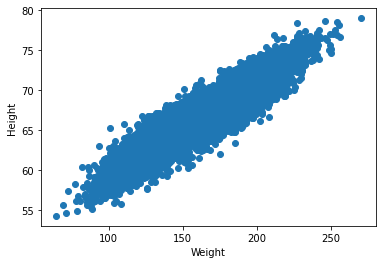

In [4]:
##scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [5]:
##Correlation
df.corr()

,Height,Weight
Height,1.000000,0.924756
Weight,0.924756,1.000000


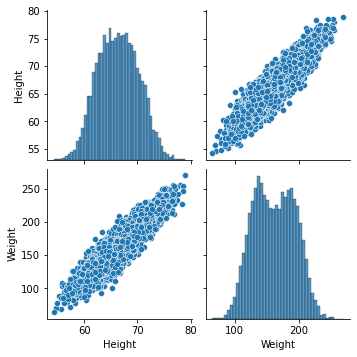

In [6]:
## Seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [7]:
##Independent and dependent features
X=df[['Weight']] # Never keep the independent variable in series format and give it to train alaways give the dataframe or 2 dimensional format
y=df['Height'] #dependent feature is ok to be in series format
X.shape

(10000, 1)

In [8]:
## Train and Test Split
from sklearn.model_selection import train_test_split

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [10]:
## Standardization is required on independent variable as to help converge faster to find global minima and mean=0 and std deviation=1 for that specific feature
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train) # fit_transform is only for train data and for test data we need to use transform
#difference between fit_transform and transform is that when we apply fit_transform to train data it calculate the mean and std deviation of that column feature and when we use transform to test data we use the same mean and std deviation to test data as well and dont compute from the begining and hence we save from data leakage program

In [12]:
X_test=scaler.transform(X_test)

In [13]:
X_test

array([[ 0.37115893],
       [ 1.05964173],
       [ 0.28064585],
       ...,
       [-1.16697743],
       [ 0.1278561 ],
       [ 0.05862451]])

In [14]:
#Apply Linear Regression
from sklearn.linear_model import LinearRegression

regression = LinearRegression(n_jobs=-1)
regression.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [15]:
print("Coefficient or slope",regression.coef_) #this is nothing but slope in equation y=mx+c where m=3.552 that is slope
print("Intercept",regression.intercept_) #this is nothing but intercept in equation y=mx+c where c= 66.34

Coefficient or slope [3.5520765]
Intercept 66.34834766153067


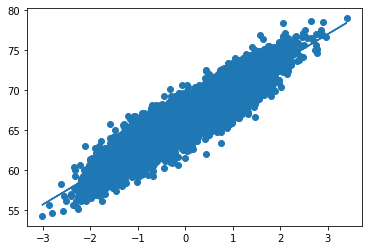

In [16]:
##plot Training data plot best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

# prediction of test data
1.predicted height output=intercept+coef_(weight)

2.y_pred_test=66.348+3.55(X_test)

In [17]:
##Prediction for test data
y_pred = regression.predict(X_test)

In [18]:
y_pred

array([67.66673256, 70.11227616, 67.3452232 , ..., 62.20315456,
       66.80250233, 66.55658642])

In [19]:
## Performance Matrix
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [20]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

2.1245002936077957
1.1618686242313918
1.4575665657553332


# R square
Formula 
R^2 = 1- SSR/SST
R^2 = coefficient of determination SSR = sum of squares of residuals SST = total sum of squares

In [21]:
from sklearn.metrics import r2_score

In [22]:
score=r2_score(y_test,y_pred)

In [23]:
print(score)

0.8574288810712688


# Adjusted R2

In [24]:
AdjR2 = 1- (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

In [25]:
AdjR2

0.8573718069644118

In [32]:
## OLS linear Regression
import statsmodels.api as sm

In [33]:
model=sm.OLS(y_train,X_train).fit()

In [34]:
prediction= model.predict(X_test)
print(prediction)

[ 1.3183849   3.7639285   0.99687554 ... -4.1451931   0.45415466
  0.20823876]


In [35]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.003
Model:                            OLS   Adj. R-squared (uncentered):              0.003
Method:                 Least Squares   F-statistic:                              21.48
Date:                Tue, 29 Apr 2025   Prob (F-statistic):                    3.63e-06
Time:                        17:15:15   Log-Likelihood:                         -42106.
No. Observations:                7500   AIC:                                  8.421e+04
Df Residuals:                    7499   BIC:                                  8.422e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [36]:
##Prediction for new data
regression.predict(scaler.transform([[72]]))

c:\users\adhadra\miniconda3\lib\site-packages\sklearn\base.py:441: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([56.45016021])